# TP04 — Analyse de sentiment (IMDB) — **TensorFlow / Keras**

**M2 DMIA — Deep Learning — Session 4**

Objectif : entraîner un **classifieur de sentiment** (positif / négatif) sur les critiques de films **IMDB**, avec une architecture **Embedding + LSTM**, et atteindre **~85–88 %** d'accuracy.

On suit le **pipeline NLP** standard :
1. Charger les données → 2. Padder (longueur fixe) → 3. Définir le modèle (Embedding + LSTM) → 4. Perte + optimiseur → 5. Entraîner → 6. Évaluer → 7. Analyser.

> 💡 Recommandé : exécuter sur **Google Colab** (Exécution → Modifier le type d'exécution → GPU).

## 0. Imports et reproductibilité

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Reproductibilite (la meme graine -> les memes resultats)
tf.random.set_seed(42)
np.random.seed(42)

print('TensorFlow version :', tf.__version__)

TensorFlow version : 2.21.0


## 1. Charger les données

IMDB est intégré à Keras : 25 000 critiques d'entraînement et 25 000 de test, **déjà tokenisées** (chaque critique est une liste d'entiers = indices de mots, triés par fréquence).

- `num_words` : on ne garde que les **10 000 mots les plus fréquents**.
- Les labels valent `0` (négatif) ou `1` (positif).

In [2]:
NUM_WORDS = 10000   # taille du vocabulaire
MAXLEN = 200        # longueur fixe des sequences (padding/troncature)

(x_train, y_train), (x_test, y_test) = keras.datasets.imdb.load_data(num_words=NUM_WORDS)

print('x_train :', len(x_train), 'critiques | x_test :', len(x_test), 'critiques')
print('Exemple de critique (indices) :', x_train[0][:15], '...')
print('Label (0=negatif, 1=positif) :', y_train[0])
print('Longueurs (min/moy/max) :', min(map(len, x_train)),
      int(np.mean([len(s) for s in x_train])), max(map(len, x_train)))

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
x_train : 25000 critiques | x_test : 25000 critiques
Exemple de critique (indices) : [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4] ...
Label (0=negatif, 1=positif) : 1
Longueurs (min/moy/max) : 11 238 2494


### Bonus : relire une critique en clair

Le dataset fournit un dictionnaire mot -> indice. On l'inverse pour reconstruire le texte (les 3 premiers indices sont réservés : padding, début, inconnu).

In [3]:
word_index = keras.datasets.imdb.get_word_index()
# decalage de 3 : indices 0,1,2 reserves
index_word = {v + 3: k for k, v in word_index.items()}
index_word[0] = '<PAD>'
index_word[1] = '<START>'
index_word[2] = '<UNK>'

def decode(seq):
    return ' '.join(index_word.get(i, '?') for i in seq)

print('Critique decodee (extrait) :')
print(decode(x_train[0])[:300], '...')

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Critique decodee (extrait) :
<START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNK> is an amazing actor and now the same being director <UNK> father came from the same scottish island as myself so i loved the ...


## 2. Padder les séquences

Les critiques ont des longueurs différentes ; un batch doit être **rectangulaire**. On fixe `MAXLEN=200` : on **tronque** les critiques trop longues et on **complète** (padding avec `0`) les trop courtes.

In [4]:
x_train = keras.preprocessing.sequence.pad_sequences(x_train, maxlen=MAXLEN)
x_test  = keras.preprocessing.sequence.pad_sequences(x_test,  maxlen=MAXLEN)

print('Apres padding :')
print('x_train :', x_train.shape, '| x_test :', x_test.shape)
print('Exemple (debut, avec padding a gauche) :', x_train[0][:20])

Apres padding :
x_train : (25000, 200) | x_test : (25000, 200)
Exemple (debut, avec padding a gauche) : [  5  25 100  43 838 112  50 670   2   9  35 480 284   5 150   4 172 112
 167   2]


## 3. Définir le modèle (Embedding + LSTM)

- **Embedding** : transforme chaque indice de mot en un vecteur dense de dimension 32 (table apprise `10000 x 32`).
- **LSTM** : 64 unités, lit la séquence et résume le sentiment dans son état final.
- **Dropout** : régularisation (IMDB sur-apprend vite).
- **Dense(1, sigmoïde)** : probabilité de la classe positive.

In [5]:
EMBED_DIM = 32

model = keras.Sequential([
    layers.Input(shape=(MAXLEN,)),
    layers.Embedding(input_dim=NUM_WORDS, output_dim=EMBED_DIM),
    layers.LSTM(64),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')   # sortie : p(positif)
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 344,897 (1.32 MB)

 Trainable params: 344,897 (1.32 MB)

 Non-trainable params: 0 (0.00 B)

## 4. Perte + optimiseur

- **Optimiseur** : Adam.
- **Perte** : `binary_crossentropy` (classification binaire).
- **Métrique** : accuracy.

In [6]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

## 5. Entraîner

On entraîne sur 4 époques, avec 20 % des données d'entraînement réservées en **validation** pour surveiller le sur-apprentissage.

In [7]:
history = model.fit(
    x_train, y_train,
    epochs=4,
    batch_size=128,
    validation_split=0.2
)

Epoch 1/4
157/157 ━━━━━━━━━━━━━━━━━━━━ 13s 77ms/step - accuracy: 0.7288 - loss: 0.5207 - val_accuracy: 0.8542 - val_loss: 0.3455
Epoch 2/4
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 73ms/step - accuracy: 0.8898 - loss: 0.2750 - val_accuracy: 0.8728 - val_loss: 0.3085
Epoch 3/4
157/157 ━━━━━━━━━━━━━━━━━━━━ 17s 109ms/step - accuracy: 0.9208 - loss: 0.2130 - val_accuracy: 0.8448 - val_loss: 0.3697
Epoch 4/4
157/157 ━━━━━━━━━━━━━━━━━━━━ 20s 124ms/step - accuracy: 0.9337 - loss: 0.1859 - val_accuracy: 0.8518 - val_loss: 0.3533


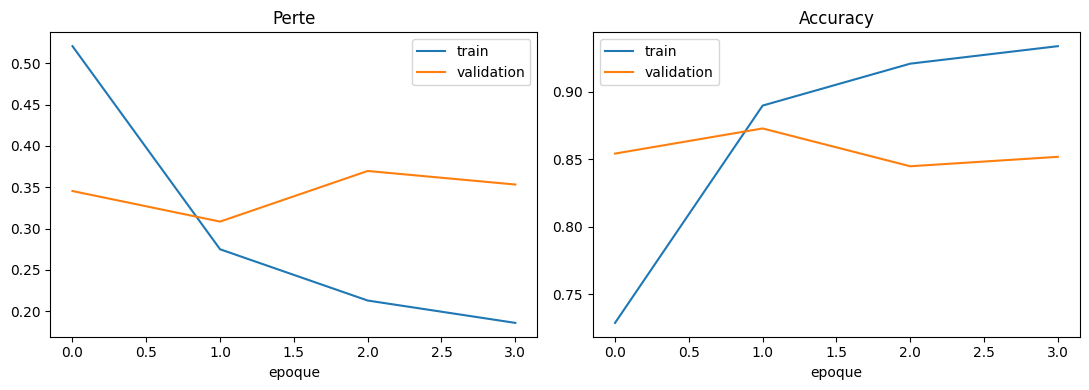

In [8]:
# Courbes d'apprentissage
plt.figure(figsize=(11, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='validation')
plt.title('Perte'); plt.xlabel('epoque'); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='validation')
plt.title('Accuracy'); plt.xlabel('epoque'); plt.legend()
plt.tight_layout(); plt.show()

## 6. Évaluer sur le jeu de test

In [9]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f'Accuracy sur le test : {test_acc:.4f}  (perte : {test_loss:.4f})')

Accuracy sur le test : 0.8524  (perte : 0.3622)


## 7. Analyser : matrice de confusion et erreurs

782/782 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step


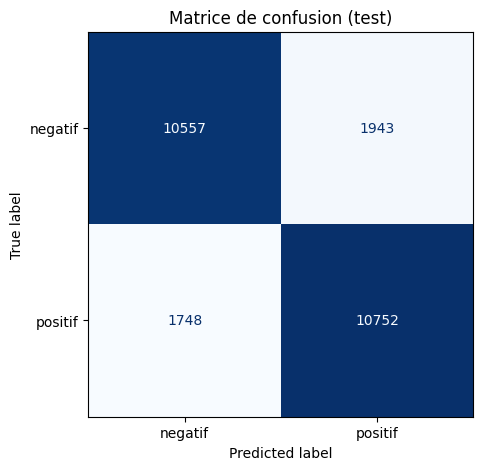

In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

probs = model.predict(x_test).ravel()
y_pred = (probs >= 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay(cm, display_labels=['negatif', 'positif']).plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Matrice de confusion (test)')
plt.show()

In [11]:
# Quelques erreurs du modele (critiques mal classees)
errors = np.where(y_pred != y_test)[0]
print('Nombre d\'erreurs :', len(errors), 'sur', len(y_test))

for idx in errors[:3]:
    print('\n--- vrai :', y_test[idx], '| predit :', y_pred[idx], f'(p={probs[idx]:.2f}) ---')
    print(decode(x_test[idx])[:300], '...')

Nombre d'erreurs : 3691 sur 25000

--- vrai : 0 | predit : 1 (p=0.97) ---
<PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD>  ...

--- vrai : 1 | predit : 0 (p=0.04) ---
<PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD>  ...

--- vrai : 1 | predit : 0 (p=0.12) ---
just looking at it so we have a film about a director who <UNK> stories by simple observation and the matter of the four stories is about how the visual imagination <UNK> love br br the film emerges by giving us the tools to bring it in

## 8. À toi de jouer 

Modifie le réseau et observe l'effet sur l'accuracy de test **et le temps d'entraînement** :
1. **GRU vs LSTM** : remplace `layers.LSTM(64)` par `layers.GRU(64)`. Compare accuracy et temps.
2. **Longueur de séquence** : fais varier `MAXLEN` (100, 200, 400) — effet sur l'accuracy ?
3. **Bidirectionnel** : enveloppe la couche dans `layers.Bidirectional(layers.LSTM(64))`.
4. **Vocabulaire** : augmente `NUM_WORDS` (20000) — le modèle s'améliore-t-il ?
5. **Question** : à partir de quelle époque observes-tu du **sur-apprentissage** (val_loss qui remonte) ?

> Note tes résultats dans un petit tableau (config → accuracy test → temps).

In [12]:
# Ton espace d'experimentation
# ...
